**Paper Airplane Challenge**

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Set the font family and size to use for Matplotlib figures
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 12

In [4]:
# Model parameters.
g = 9.81         # gravitational acceleration (m/s**2)
v_t = 4.9        # trim speed (m/s)
C_D = 1.0 / 5.0  # drag coefficient
C_L = 1.0        # lift coefficient

# Initial conditions.
v_0 = 6.5       # initial speed, above the trim speed (m/s)
theta_0 = -0.1  # trajectory angle (rad)
x_0 = 0.0       # horizontal position (m)
y_0 = 2.0       # altitude (m)

In [5]:
from urllib.request import urlretrieve

url = (
'https://jupyter.lai.gwu.edu/user/g31257740/files/Numerical/phugoid.txt?_xsrf=MnwxOjB8MTA6MTc5MDQ1Mz'
'AwN3w1Ol94c3JmfDEzMjpOVGRrTVdNek5tRTVaREk1TkRFM1pqZzBOV1UxTlRVMFpUUTNZamxqTlRZNlpqZ3lZVEU0T1dRMlpUTX'
'lOVFptWldJNU16a3lNelprWVRNNFlqVmxOMlJqTW1aa01HSXlNMlEzT1Rsa1l6bGhZVFU0WkdSbU4yTmhZbUk0TjJFeU9BPT18Mj'
'Q5ZmZkYWViOTE1MTVhODEzODM5OGEyMGVlYjBlZWQzMjc0MTZkOTNhNjgxODRjZmMzYTM4YzEzNWY3OWE1Nw'
)
fname = 'phugoid1.py'
urlretrieve(url, fname)

('phugoid1.py', <http.client.HTTPMessage at 0x7f13ccbf6690>)

In [6]:
from phugoid import (
    discrete_l1_difference,
    euler_step,
    rhs_full_phugoid,
)

**The second-order Runge-Kutta method (RK2)** is a numerical technique used to solve first-order ordinary differential equations by estimating slopes at multiple points within a step to achieve second-order accuracy

In [7]:
def rk2_step(u, f, dt, *args):
    '''Return the next state using the second-order Runge–Kutta method.

    Parameters
    ----------
    u : np.ndarray
        State at the current time
        as a 1D array of floats.
    f : function
        Function to compute the right-hand side of the system.
    dt : float
        Time-step size.
    *args
        Additional positional arguments passed to f.

    Returns
    -------
    u_new : np.ndarray
        The solution at the next time step
        as a 1D array of floats.
    '''
    u_star = u + 0.5 * dt * f(u, *args)
    u_new = u + dt * f(u_star, *args)
    return u_new

In [8]:
T_trajectory = 2.0  # common pre-impact interval (s)
dt = 0.01  # time-step size (s)
num_steps = int(round(T_trajectory / dt))

# Store the state at every time point, including the initial state.
u_euler = np.empty((num_steps + 1, 4))
u_rk2 = np.empty((num_steps + 1, 4))
u_euler[0] = np.array([v_0, theta_0, x_0, y_0])
u_rk2[0] = np.array([v_0, theta_0, x_0, y_0])

# Advance both methods over the same time grid.
for n in range(num_steps):
    u_euler[n + 1] = euler_step(
        u_euler[n], rhs_full_phugoid, dt, C_L, C_D, g, v_t
    )
    u_rk2[n + 1] = rk2_step(
        u_rk2[n], rhs_full_phugoid, dt, C_L, C_D, g, v_t
    )

In [9]:
# Extract the common time grid and both position histories.
t_trajectory = np.linspace(0.0, T_trajectory, num_steps + 1)
x_euler = u_euler[:, 2]
y_euler = u_euler[:, 3]
x_rk2 = u_rk2[:, 2]
y_rk2 = u_rk2[:, 3]
print(f'Final Euler altitude: {y_euler[-1]:.3f} m')
print(f'Final RK2 altitude:   {y_rk2[-1]:.3f} m')

Final Euler altitude: 0.718 m
Final RK2 altitude:   0.743 m


**Lets Explore how these two values interact visually**

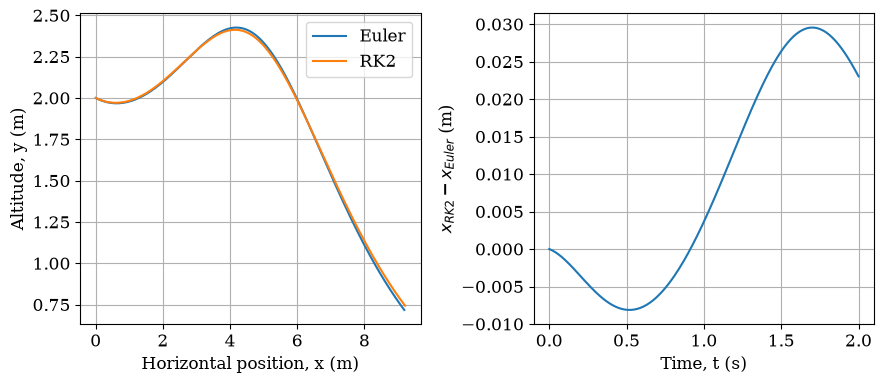

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(9.0, 4.0))
for ax in axes:
    ax.grid()
    ax.set_xlabel('Horizontal position, x (m)')
    ax.set_ylabel('Altitude, y (m)')

# Plot both approximations over the common pre-impact interval.
axes[0].plot(x_euler, y_euler, label='Euler')
axes[0].plot(x_rk2, y_rk2, label='RK2')
axes[0].legend()

# Plot their horizontal separation on the same time grid.
axes[1].plot(t_trajectory, x_rk2 - x_euler)
axes[1].set_xlabel('Time, t (s)')
axes[1].set_ylabel(r'$x_{RK2} - x_{Euler}$ (m)')
fig.tight_layout()

**Make our array with the data**

In [11]:
# Set the time-step sizes to investigate.
dt_values = [0.1, 0.05, 0.01, 0.005, 0.001]
u_histories = []

for dt_trial in dt_values:
    num_steps_trial = int(round(T_trajectory / dt_trial))
    u_trial = np.empty((num_steps_trial + 1, 4))
    u_trial[0] = np.array([v_0, theta_0, x_0, y_0])

    for n in range(num_steps_trial):
        u_trial[n + 1] = rk2_step(
            u_trial[n], rhs_full_phugoid, dt_trial,
            C_L, C_D, g, v_t,
        )
    u_histories.append(u_trial)

In [12]:
# Compute the differences in horizontal position.
difference_values = []
for u_trial, dt_trial in zip(u_histories, dt_values, strict=True):
    difference = discrete_l1_difference(
        u_trial[:, 2], u_histories[-1][:, 2],
        dt_trial, dt_values[-1],
    )
    difference_values.append(difference)

**Plot the differences**

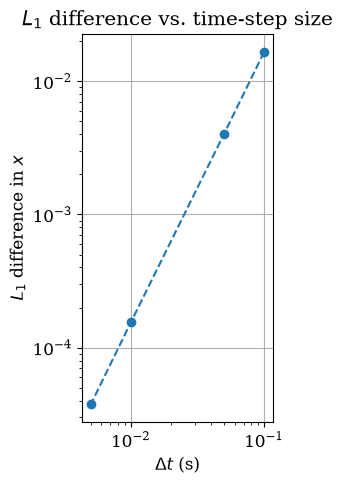

In [13]:
fig, ax = plt.subplots(figsize=(5.0, 5.0))
ax.set_title(r'$L_1$ difference vs. time-step size')
ax.set_xlabel(r'$\Delta t$ (s)')
ax.set_ylabel(r'$L_1$ difference in $x$')
ax.grid()
ax.loglog(
    dt_values[:-1], difference_values[:-1],
    color='tab:blue', linestyle='--', marker='o',
)
ax.set_aspect('equal', adjustable='box')
fig.tight_layout()

**Lets see if our $p \approx 2$** (second Order)

In [14]:
refinement_ratio = 2
dt_fine = 0.001
dt_order = [
    dt_fine,
    refinement_ratio * dt_fine,
    refinement_ratio**2 * dt_fine,
]
u_order = []

for dt_trial in dt_order:
    num_steps_trial = int(round(T_trajectory / dt_trial))
    u_trial = np.empty((num_steps_trial + 1, 4))
    u_trial[0] = np.array([v_0, theta_0, x_0, y_0])

    for n in range(num_steps_trial):
        u_trial[n + 1] = rk2_step(
            u_trial[n], rhs_full_phugoid, dt_trial,
            C_L, C_D, g, v_t,
        )
    u_order.append(u_trial)

# Compare horizontal position on the three grids.
difference_coarse_medium = discrete_l1_difference(
    u_order[2][:, 2], u_order[1][:, 2],
    dt_order[2], dt_order[1],
)
difference_medium_fine = discrete_l1_difference(
    u_order[1][:, 2], u_order[0][:, 2],
    dt_order[1], dt_order[0],
)
difference_ratio = difference_coarse_medium / difference_medium_fine
observed_order = (
    np.log(difference_ratio) / np.log(refinement_ratio)
)

print(f'Coarse–medium difference: {difference_coarse_medium:.6e} m s')
print(f'Medium–fine difference:   {difference_medium_fine:.6e} m s')
print(f'Difference ratio:         {difference_ratio:.3f}')
print(f'Observed order:           p = {observed_order:.3f}')

Coarse–medium difference: 1.880804e-05 m s
Medium–fine difference:   4.695819e-06 m s
Difference ratio:         4.005
Observed order:           p = 2.002


**Locate Touchdown**

In [15]:
def locate_touchdown(t, u, t_next, u_next):
    '''Interpolate the ground crossing inside one bracketing step.

    Parameters
    ----------
    t, t_next : float
        Times at the start and end of the bracketing step.
    u, u_next : np.ndarray
        States at those times, with u[3] > 0 and u_next[3] <= 0.

    Returns
    -------
    t_touchdown : float
        Interpolated time of the crossing.
    u_touchdown : np.ndarray
        Interpolated state at the crossing.
    '''
    alpha = u[3] / (u[3] - u_next[3])
    t_touchdown = t + alpha * (t_next - t)
    u_touchdown = u + alpha * (u_next - u)
    return t_touchdown, u_touchdown


In [16]:
u_above = np.array([6.0, -0.2, 5.0, 0.3])
u_below = np.array([6.1, -0.2, 5.06, -0.1])
t_check, u_check = locate_touchdown(2.0, u_above, 2.01, u_below)

np.testing.assert_allclose(t_check, 2.0075)
np.testing.assert_allclose(u_check, [6.075, -0.2, 5.045, 0.0])


In [17]:
def range_first_draft(step_function, u_0, f, dt, time_limit, *args):
    '''Return a status and range from a loop with no validity checks.'''
    u = np.asarray(u_0, dtype=float)
    x_initial = u[2]
    for n in range(int(np.floor(time_limit / dt))):
        u_next = step_function(u, f, dt, *args)
        if u_next[3] <= 0.0:
            t_touchdown, u_touchdown = locate_touchdown(
                n * dt, u, (n + 1) * dt, u_next
            )
            return 'touchdown', u_touchdown[2] - x_initial
        u = u_next
    return 'time_limit', None


In [18]:
def range_first_draft(step_function, u_0, f, dt, time_limit, *args):
    '''Return a status and range from a loop with no validity checks.'''
    u = np.asarray(u_0, dtype=float)
    x_initial = u[2]
    for n in range(int(np.floor(time_limit / dt))):
        u_next = step_function(u, f, dt, *args)
        if u_next[3] <= 0.0:
            t_touchdown, u_touchdown = locate_touchdown(
                n * dt, u, (n + 1) * dt, u_next
            )
            return 'touchdown', u_touchdown[2] - x_initial
        u = u_next
    return 'time_limit', None


In [19]:
u_baseline = np.array([v_0, theta_0, x_0, y_0])
print(range_first_draft(
    euler_step, u_baseline, rhs_full_phugoid, 0.01, 15.0, C_L, C_D, g, v_t
))

u_zero_speed = np.array([0.0, theta_0, x_0, y_0])
print(range_first_draft(
    euler_step, u_zero_speed, rhs_full_phugoid, 0.01, 15.0, C_L, C_D, g, v_t
))


('touchdown', np.float64(14.594430989594155))
('time_limit', None)


/home/jovyan/Numerical/phugoid.py:27: RuntimeWarning: divide by zero encountered in scalar divide
  -(g / v) * np.cos(theta) + (g / v_t**2) * v,
/home/jovyan/Numerical/phugoid.py:26: RuntimeWarning: invalid value encountered in sin
  -g * np.sin(theta) - (C_D / C_L) * (g / v_t**2) * v**2,
/home/jovyan/Numerical/phugoid.py:27: RuntimeWarning: invalid value encountered in cos
  -(g / v) * np.cos(theta) + (g / v_t**2) * v,
/home/jovyan/Numerical/phugoid.py:28: RuntimeWarning: invalid value encountered in cos
  v * np.cos(theta),
/home/jovyan/Numerical/phugoid.py:29: RuntimeWarning: invalid value encountered in sin
  v * np.sin(theta),


In [20]:
print(np.nan <= 0.0, np.nan > 0.0, np.isfinite(np.nan))



False False False


A state is valid when every entry is finite and the speed is positive: negative speed is outside the state convention, and zero speed is outside the model’s domain. A nonpositive altitude reached from a positive altitude is the event, not an invalid state.

**Run a test to check if its a vali state**

In [21]:
def state_is_valid(u):
    '''Return True when every entry is finite and the speed is positive.'''
    return np.all(np.isfinite(u)) and u[0] > 0.0


assert state_is_valid(u_baseline)
assert not state_is_valid(u_zero_speed)
assert not state_is_valid(np.array([np.nan, theta_0, x_0, y_0]))


In [22]:
def integrate_until_touchdown(
    step_function, u_0, f, dt, time_limit, *args
):
    '''Integrate until touchdown, the time limit, or an invalid state.'''
    if dt <= 0.0:
        raise ValueError('dt must be positive.')

    u = np.asarray(u_0, dtype=float)
    if u.shape != (4,) or u[3] <= 0.0:
        raise ValueError(
            'u_0 must contain [v, theta, x, y] with positive altitude.'
        )
    x_initial = u[2]

    max_steps = int(np.floor(time_limit / dt))
    times = [0.0]
    states = [u.copy()]
    status = 'time_limit'
    touchdown_time = None
    touchdown_state = None
    range_value = None

    for n in range(max_steps):
        u_next = step_function(u, f, dt, *args)

        if not state_is_valid(u_next):
            status = 'invalid_state'
            break

        t_next = (n + 1) * dt
        times.append(t_next)
        states.append(u_next)

        if u_next[3] <= 0.0:
            touchdown_time, touchdown_state = locate_touchdown(
                n * dt, u, t_next, u_next
            )
            range_value = touchdown_state[2] - x_initial
            status = 'touchdown'
            break

        u = u_next

    return {
        'status': status,
        'times': np.asarray(times),
        'states': np.asarray(states),
        'touchdown_time': touchdown_time,
        'touchdown_state': touchdown_state,
        'range': range_value,
        'steps': len(times) - 1,
    }


**Check the non-success outcomes**

In [23]:
unfinished_result = integrate_until_touchdown(
    euler_step, u_baseline, rhs_full_phugoid,
    0.01, 0.1, C_L, C_D, g, v_t,
)
invalid_result = integrate_until_touchdown(
    euler_step, u_zero_speed, rhs_full_phugoid,
    0.01, 15.0, C_L, C_D, g, v_t,
)

for result in (unfinished_result, invalid_result):
    print(
        f'{result["status"]}: range = {result["range"]}; '
        f'{result["steps"]} accepted steps'
    )

assert unfinished_result['status'] == 'time_limit'
assert unfinished_result['range'] is None
assert unfinished_result['steps'] == 10
assert invalid_result['status'] == 'invalid_state'
assert invalid_result['range'] is None
assert invalid_result['steps'] == 0


time_limit: range = None; 10 accepted steps
invalid_state: range = None; 0 accepted steps


**This is the standard way to test that a function rejects invalid input without stopping the calculation. The final assert would fail if the guard were removed.**

In [24]:
u_below_ground = np.array([v_0, theta_0, x_0, -1.0])
guard_triggered = False
try:
    integrate_until_touchdown(
        euler_step, u_below_ground, rhs_full_phugoid,
        0.01, 15.0, C_L, C_D, g, v_t,
    )
except ValueError as error:
    guard_triggered = True
    print('Rejected:', error)

assert guard_triggered


Rejected: u_0 must contain [v, theta, x, y] with positive altitude.


The flow is: 
\
Negative altitude supplied
        ↓
\Function raises ValueError
        ↓
\except catches it
        ↓
\guard_triggered becomes True
        ↓
\assert passes

In [25]:
eta = C_D / C_L
theta_steady = -np.arctan(eta)
v_steady = v_t * np.sqrt(np.cos(theta_steady))
u_steady = np.array([v_steady, theta_steady, 0.0, y_0])
exact_steady_time = -y_0 / (v_steady * np.sin(theta_steady))
exact_steady_range = y_0 * C_L / C_D
verification_dts = [0.5, 0.4, 0.25]

print('method      dt (s)   touchdown (s)   range (m)   error (m)')
for method_name, step_function in (
    ('Euler', euler_step), ('RK2', rk2_step)
):
    for dt_trial in verification_dts:
        result = integrate_until_touchdown(
            step_function, u_steady, rhs_full_phugoid,
            dt_trial, 15.0, C_L, C_D, g, v_t,
        )
        assert result['status'] == 'touchdown'
        range_error = abs(result['range'] - exact_steady_range)
        print(
            f'{method_name:<8} {dt_trial:8.2f} '
            f'{result["touchdown_time"]:15.9f} '
            f'{result["range"]:11.9f} {range_error:11.3e}'
        )

        assert (
            result['times'][-2]
            < result['touchdown_time']
            < result['times'][-1]
        )
        assert abs(result['touchdown_time'] - exact_steady_time) < 1e-10
        assert range_error < 1e-10

method      dt (s)   touchdown (s)   range (m)   error (m)
Euler        0.50     2.101739684 10.000000000   3.553e-15
Euler        0.40     2.101739684 10.000000000   3.553e-15
Euler        0.25     2.101739684 10.000000000   3.553e-15
RK2          0.50     2.101739684 10.000000000   3.553e-15
RK2          0.40     2.101739684 10.000000000   0.000e+00
RK2          0.25     2.101739684 10.000000000   1.776e-15


In [26]:
dt_touchdown = 0.01
time_limit = 15.0
rhs_calls_per_step = {'Euler': 1, 'RK2': 2}
flight_results = {}

for method_name, step_function in (
    ('Euler', euler_step), ('RK2', rk2_step)
):
    result = integrate_until_touchdown(
        step_function, u_baseline, rhs_full_phugoid,
        dt_touchdown, time_limit, C_L, C_D, g, v_t,
    )
    flight_results[method_name] = result
    work = result['steps'] * rhs_calls_per_step[method_name]

    if result['range'] is None:
        print(
            f'{method_name}: {result["status"]}; '
            f'range unavailable; {work} RHS evaluations'
        )
    else:
        print(
            f'{method_name}: {result["status"]}; '
            f't = {result["touchdown_time"]:.6f} s; '
            f'R = {result["range"]:.6f} m; '
            f'{work} RHS evaluations'
        )


Euler: touchdown; t = 3.089928 s; R = 14.594431 m; 309 RHS evaluations
RK2: touchdown; t = 3.073395 s; R = 14.531319 m; 616 RHS evaluations


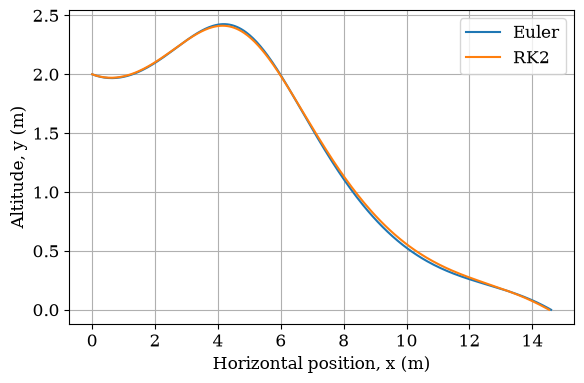

In [27]:
fig, ax = plt.subplots(figsize=(6.0, 4.0))
for method_name, result in flight_results.items():
    path = result['states'].copy()
    if result['status'] == 'touchdown':
        # Replace the below-ground bracket endpoint by the event point.
        path[-1] = result['touchdown_state']
    ax.plot(path[:, 2], path[:, 3], label=method_name)

ax.set_xlabel('Horizontal position, x (m)')
ax.set_ylabel('Altitude, y (m)')
ax.grid()
ax.legend()
fig.tight_layout()

**Establish a numerical range reference**

In [28]:
range_target = 0.01 # required numerical range accuracy (m)
reference_tolerance = 0.01 * range_target  # a reference must beat the target
dt_reference = dt_touchdown
result = integrate_until_touchdown(
    rk2_step, u_baseline, rhs_full_phugoid,
    dt_reference, time_limit, C_L, C_D, g, v_t,
)
range_previous = result['range']
reference_work = result['steps'] * rhs_calls_per_step['RK2']
small_changes = 0
reference_accepted = False

print('dt (s)         range (m)    change (m)')
print(f'{dt_reference:<12.6f} {range_previous:12.6f}')
for halving in range(8):
    dt_reference = dt_reference / 2
    result = integrate_until_touchdown(
        rk2_step, u_baseline, rhs_full_phugoid,
        dt_reference, time_limit, C_L, C_D, g, v_t,
    )
    assert result['status'] == 'touchdown'
    reference_work += result['steps'] * rhs_calls_per_step['RK2']
    change = abs(result['range'] - range_previous)
    print(f'{dt_reference:<12.6f} {result["range"]:12.6f} {change:12.3e}')
    range_previous = result['range']

    if change < reference_tolerance:
        small_changes += 1
    else:
        small_changes = 0
    if small_changes == 2:
        reference_accepted = True
        break

assert reference_accepted, 'Insufficient evidence for a range reference.'
range_reference = range_previous
dt_search = dt_reference
print(f'Reference range: {range_reference:.6f} m at dt_search = {dt_search:g} s')
print(f'Work to establish the reference: {reference_work} RHS evaluations')


dt (s)         range (m)    change (m)
0.010000        14.531319
0.005000        14.531054    2.651e-04
0.002500        14.530989    6.486e-05
0.001250        14.530973    1.621e-05
Reference range: 14.530973 m at dt_search = 0.00125 s
Work to establish the reference: 9224 RHS evaluations


# Stage 1 Grid Refinement Task Instructions

## Title

Stage 1 Grid Refinement & Efficiency Analysis for `Paper_airplane.ipynb`

## Goal and Scope

Execute and document the Stage 1 grid refinement study comparing **Euler** and **RK2** integration methods against a shared reference range ($R_{\text{ref}}$) to identify which method meets the $1\text{ cm}$ ($0.01\text{ m}$) range accuracy target with the least computational work. Scope is strictly limited to appending execution and reporting cells to the end of the existing `Paper_airplane.ipynb` notebook.

## Non-Negotiables

* **Zero Modifications:** Do **NOT** edit, overwrite, modify, or delete any existing cells, code, markdown, or variables in `Paper_airplane.ipynb`.
* **Add Cells Only:** All new code and text must be appended as new cells at the bottom of the notebook.
* **No Code Refactoring:** Do not redefine existing functions or re-initialize model parameters.
* **Variable Reuse:** Use existing notebook symbols directly (`u_baseline`, `rhs_full_phugoid`, `integrate_until_touchdown`, `euler_step`, `rk2_step`, `rhs_calls_per_step`, `time_limit`, `C_L`, `C_D`, `g`, `v_t`, and `dt_touchdown`).

## Allowed Actions

* **Append Cell 1 (Code):** Run the reference range search, Euler cross-check, and grid refinement loops ($\Delta t = 0.1, 0.05, 0.025, \dots$) for both methods. Print the results table and work totals.
* **Append Cell 2 (Code):** Plot error versus work (RHS calls) on a **log-log graph** with a $0.01\text{ m}$ threshold line.
* **Append Cell 3 (Markdown):** Document the final table, selected step sizes, supporting finer step checks, and the efficiency verdict.

## Done When

* **Cell 1 runs cleanly:** Calculates $R_{\text{ref}}$, runs the step-halving loops until meeting target accuracy plus a supporting finer run, and prints the full data table with work totals.
* **Cell 2 renders correctly:** Displays a log-log plot showing error versus work against the $0.01\text{ m}$ target line.
* **Cell 3 is complete:** Summarizes that RK2 qualifies at $\Delta t = 0.05\text{ s}$ ($600$ calls) and Euler at $\Delta t = 0.0015625\text{ s}$ ($9,600$ calls), confirming RK2 is **16 times more work-efficient**.
* **Notebook untouched:** All existing cells in `Paper_airplane.ipynb` remain original and unmodified.

In [30]:
# Stage 1: append-only study; all new state is isolated in stage1_* names.
stage1 = {'target': 0.01, 'reference_tolerance': 0.0001,
          'reference_work': 0, 'euler_crosscheck_work': 0,
          'reference_rows': [], 'crosscheck_rows': [], 'rows': [],
          'selected': {}, 'search_work': {}}
stage1_dt = dt_touchdown
stage1_previous = None
stage1_small_changes = 0
for stage1_k in range(20):
    stage1_run = integrate_until_touchdown(
        rk2_step, u_baseline, rhs_full_phugoid,
        stage1_dt, time_limit, C_L, C_D, g, v_t)
    assert stage1_run['status'] == 'touchdown', stage1_run['status']
    stage1_work = stage1_run['steps'] * rhs_calls_per_step['RK2']
    stage1['reference_work'] += stage1_work
    stage1_change = (abs(stage1_run['range'] - stage1_previous)
                     if stage1_previous is not None else float('nan'))
    stage1['reference_rows'].append(
        (stage1_dt, stage1_run['range'], stage1_change, stage1_work))
    stage1_small_changes = (stage1_small_changes + 1
                           if stage1_change < stage1['reference_tolerance'] else 0)
    stage1_previous = stage1_run['range']
    if stage1_small_changes >= 2:
        break
    stage1_dt /= 2
else:
    raise RuntimeError('Reference search did not converge.')
stage1['R_ref'] = stage1_run['range']
stage1['dt_ref'] = stage1_dt

# Independent Euler cross-check to the same 0.1 mm reference tolerance.
for stage1_k in range(20):
    stage1_run = integrate_until_touchdown(
        euler_step, u_baseline, rhs_full_phugoid,
        stage1_dt, time_limit, C_L, C_D, g, v_t)
    assert stage1_run['status'] == 'touchdown', stage1_run['status']
    stage1_work = stage1_run['steps'] * rhs_calls_per_step['Euler']
    stage1['euler_crosscheck_work'] += stage1_work
    stage1_error = abs(stage1_run['range'] - stage1['R_ref'])
    stage1['crosscheck_rows'].append(
        (stage1_dt, stage1_run['range'], stage1_error, stage1_work))
    if stage1_error < stage1['reference_tolerance']:
        break
    stage1_dt /= 2
else:
    raise RuntimeError('Euler cross-check did not converge.')

# Start at 0.1 s; retain two finer grids after each first qualifying grid.
for stage1_method, stage1_step in (('Euler', euler_step), ('RK2', rk2_step)):
    stage1_dt = 0.1
    stage1_cumulative = 0
    stage1_finer = 0
    for stage1_k in range(25):
        stage1_run = integrate_until_touchdown(
            stage1_step, u_baseline, rhs_full_phugoid,
            stage1_dt, time_limit, C_L, C_D, g, v_t)
        assert stage1_run['status'] == 'touchdown', stage1_run['status']
        stage1_work = stage1_run['steps'] * rhs_calls_per_step[stage1_method]
        stage1_cumulative += stage1_work
        stage1_error = abs(stage1_run['range'] - stage1['R_ref'])
        stage1_row = dict(
            method=stage1_method, dt=stage1_dt, range=stage1_run['range'],
            error=stage1_error, rhs=stage1_work,
            budget=int(np.floor(time_limit / stage1_dt)) * rhs_calls_per_step[stage1_method],
            cumulative=stage1_cumulative, qualifies=stage1_error <= stage1['target'])
        stage1['rows'].append(stage1_row)
        if stage1_method in stage1['selected']:
            assert stage1_row['qualifies'], 'Finer grid failed the target.'
            stage1_finer += 1
        elif stage1_row['qualifies']:
            stage1['selected'][stage1_method] = stage1_row
        if stage1_finer == 2:
            break
        stage1_dt /= 2
    else:
        raise RuntimeError('Grid search did not finish.')
    stage1['search_work'][stage1_method] = stage1_cumulative

print('RK2 reference search: dt (s), range (m), change (m), actual RHS')
for stage1_entry in stage1['reference_rows']:
    print(f'{stage1_entry[0]:.9g}  {stage1_entry[1]:.10f}  {stage1_entry[2]:.6e}  {stage1_entry[3]:,}')
print(f"R_ref = {stage1['R_ref']:.10f} m; reference_work = {stage1['reference_work']:,}")
print('\nEuler cross-check: dt (s), range (m), |R - R_ref| (m), actual RHS')
for stage1_entry in stage1['crosscheck_rows']:
    print(f'{stage1_entry[0]:.9g}  {stage1_entry[1]:.10f}  {stage1_entry[2]:.6e}  {stage1_entry[3]:,}')
print(f"euler_crosscheck_work = {stage1['euler_crosscheck_work']:,}")
print('\nMethod  dt (s)       Range (m)      |R-R_ref| (m) Actual RHS  15s budget  Cumul. RHS  Pass')
for stage1_row in stage1['rows']:
    print(f"{stage1_row['method']:<6}  {stage1_row['dt']:<12.9g} "
          f"{stage1_row['range']:13.9f}  {stage1_row['error']:13.6e} "
          f"{stage1_row['rhs']:10,d}  {stage1_row['budget']:10,d}  "
          f"{stage1_row['cumulative']:10,d}  {stage1_row['qualifies']}")
print('\nLeast-work qualifying tested grids:')
for stage1_method, stage1_row in stage1['selected'].items():
    print(f"{stage1_method}: dt = {stage1_row['dt']:g} s, "
          f"{stage1_row['rhs']:,} actual RHS, {stage1_row['budget']:,} full-horizon budget")
print(f"Budget work ratio Euler/RK2: {stage1['selected']['Euler']['budget'] / stage1['selected']['RK2']['budget']:.6g}")
print(f"Actual work ratio Euler/RK2: {stage1['selected']['Euler']['rhs'] / stage1['selected']['RK2']['rhs']:.6g}")
print(f"Refinement work (including finer checks): {stage1['search_work']}")
print(f"Total study RHS: {stage1['reference_work'] + stage1['euler_crosscheck_work'] + sum(stage1['search_work'].values()):,}")


RK2 reference search: dt (s), range (m), change (m), actual RHS
0.01  14.5313190887  nan  616
0.005  14.5310539880  2.651007e-04  1,230
0.0025  14.5309891274  6.486059e-05  2,460
0.00125  14.5309729165  1.621099e-05  4,918
R_ref = 14.5309729165 m; reference_work = 9,224

Euler cross-check: dt (s), range (m), |R - R_ref| (m), actual RHS
0.00125  14.5383875794  7.414663e-03  2,461
0.000625  14.5346598674  3.686951e-03  4,919
0.0003125  14.5328093606  1.836444e-03  9,837
0.00015625  14.5318873779  9.144614e-04  19,671
7.8125e-05  14.5314272387  4.543222e-04  39,340
3.90625e-05  14.5311973746  2.244581e-04  78,678
1.953125e-05  14.5310824930  1.095766e-04  157,355
9.765625e-06  14.5310250656  5.214910e-05  314,708
euler_crosscheck_work = 626,969

Method  dt (s)       Range (m)      |R-R_ref| (m) Actual RHS  15s budget  Cumul. RHS  Pass
Euler   0.1           11.107805509   3.423167e+00         24         150          24  False
Euler   0.05          14.935155762   4.041828e-01         64    

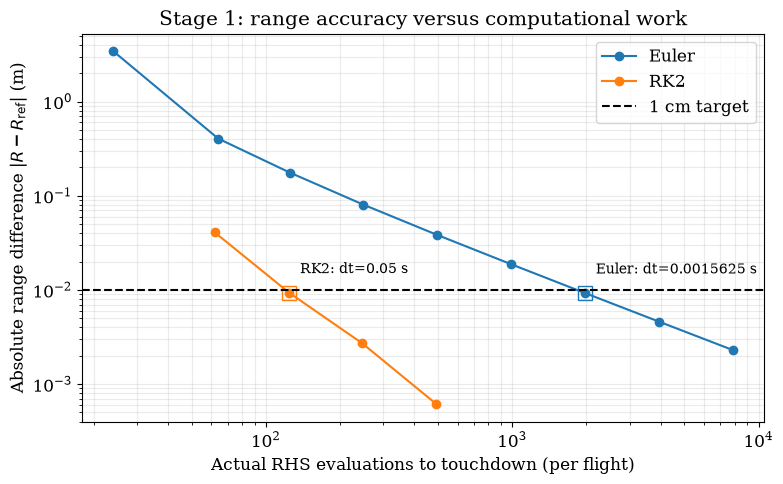

In [41]:
# Stage 1: per-flight work, excluding reference/search overhead.
stage1_fig, stage1_ax = plt.subplots(figsize=(8, 5))
for stage1_plot_method, stage1_color in (('Euler', 'tab:blue'), ('RK2', 'tab:orange')):
    stage1_plot_rows = [stage1_r for stage1_r in stage1['rows']
                        if stage1_r['method'] == stage1_plot_method]
    stage1_ax.loglog(
        [stage1_r['rhs'] for stage1_r in stage1_plot_rows],
        [stage1_r['error'] for stage1_r in stage1_plot_rows],
        'o-', color=stage1_color, label=stage1_plot_method)
    stage1_pick = stage1['selected'][stage1_plot_method]
    stage1_ax.plot(stage1_pick['rhs'], stage1_pick['error'], 's',
                   color=stage1_color, markersize=10, fillstyle='none')
    stage1_ax.annotate(
        f"{stage1_plot_method}: dt={stage1_pick['dt']:g} s",
        (stage1_pick['rhs'], stage1_pick['error']),
        xytext=(8, 14), textcoords='offset points', fontsize=10)
stage1_ax.axhline(stage1['target'], color='black', linestyle='--', label='1 cm target')
stage1_ax.set(xlabel='Actual RHS evaluations to touchdown (per flight)',
              ylabel=r'Absolute range difference $|R - R_{\mathrm{ref}}|$ (m)',
              title='Stage 1: range accuracy versus computational work')
stage1_ax.grid(True, which='both', alpha=0.25)
stage1_ax.legend()
stage1_fig.tight_layout()
plt.show()


### Stage 1 — grid refinement and efficiency results

The shared numerical reference is $R_{\mathrm{ref}}=14.5309729165\,\mathrm{m}$, obtained with RK2 at $\Delta t=0.00125\,\mathrm{s}$. Starting from the existing `dt_touchdown = 0.01` s, successive RK2 halvings changed the range by $2.651007\times10^{-4}$, $6.486059\times10^{-5}$, and $1.621099\times10^{-5}$ m. The last two changes are below the reference tolerance of $10^{-4}$ m (one hundredth of the 1 cm target). This is numerical convergence evidence, rather than an exact-solution error bound.

An independent Euler cross-check, halved from the reference step to $9.765625\times10^{-6}$ s, gives $R=14.5310250656$ m, differing from the reference by $5.214910\times10^{-5}$ m. Accumulated actual work is **reference_work = 9,224** and **euler_crosscheck_work = 626,969** RHS evaluations. These new results are stored inside `stage1`; the pre-existing `reference_work` and all other original variables are preserved.

Both method searches start at 0.1 s and halve through the first qualifying grid and two additional finer grids. All runs reached touchdown. The criterion is $|R-R_{\mathrm{ref}}|\leq0.01$ m.

| Method | Step (s) | Range (m) | Absolute difference (m) | Actual RHS | 15 s RHS budget | Cumulative search RHS | Pass |
|---|---:|---:|---:|---:|---:|---:|:---:|
| Euler | 0.1 | 11.107805509 | 3.423167 | 24 | 150 | 24 | No |
| Euler | 0.05 | 14.935155762 | 0.4041828 | 64 | 300 | 88 | No |
| Euler | 0.025 | 14.707119813 | 0.1761469 | 125 | 600 | 213 | No |
| Euler | 0.0125 | 14.611628699 | 0.08065578 | 248 | 1,200 | 461 | No |
| Euler | 0.00625 | 14.569491751 | 0.03851884 | 494 | 2,400 | 955 | No |
| Euler | 0.003125 | 14.549789599 | 0.01881668 | 986 | 4,800 | 1,941 | No |
| Euler | **0.0015625** | **14.540263895** | **0.009290979** | **1,969** | **9,600** | 3,910 | **Yes** |
| Euler | 0.00078125 | 14.535588288 | 0.004615372 | 3,936 | 19,200 | 7,846 | Yes |
| Euler | 0.000390625 | 14.533271142 | 0.002298226 | 7,870 | 38,400 | 15,716 | Yes |
| RK2 | 0.1 | 14.571737611 | 0.04076469 | 62 | 300 | 62 | No |
| RK2 | **0.05** | **14.540348306** | **0.009375390** | **124** | **600** | 186 | **Yes** |
| RK2 | 0.025 | 14.533685901 | 0.002712984 | 246 | 1,200 | 432 | Yes |
| RK2 | 0.0125 | 14.531587133 | 0.0006142166 | 492 | 2,400 | 924 | Yes |

The least-work qualifying tested steps are **RK2: 0.05 s** and **Euler: 0.0015625 s**. Their immediately coarser grids fail. The two finer Euler grids reduce the difference to 0.004615372 and 0.002298226 m; the two finer RK2 grids reduce it to 0.002712984 and 0.0006142166 m. The qualifying differences remain below 0.01 m even with a $10^{-4}$ m reference allowance.

**Efficiency verdict:** RK2 wins. Using the requested full-horizon work convention,
$W_{\mathrm{budget}}=\lfloor\mathtt{time\_limit}/\Delta t\rfloor\,n_{\mathrm{RHS}}$,
RK2 costs **600** evaluations and Euler **9,600**, so RK2 is **16 times more work-efficient by this budget measure**. The existing integrator stops at touchdown near 3.07 s, so these budgets are not evaluations actually performed: the measured per-flight costs are **124** and **1,969**, giving **15.879×** efficiency. The log-log plot uses actual per-flight RHS counts and excludes search overhead.

Accumulated refinement work, including the two supporting grids, is 15,716 RHS evaluations for Euler and 924 for RK2. Through first qualification alone it is 3,910 versus 186. Reference construction and the independent cross-check are shared validation overhead, not charged to either selected flight. Total actual work for the complete appended study is **652,833 RHS evaluations**.


Sep 26, codex **stage 2**

# Agent observed-order task brief


## Goal and scope

Add two readable, unexecuted Python cells below this brief in `Paper_airplane.ipynb`. Cell 1 searches a grid of launches. Cell 2 checks the leading launches. Leave the choice of launch and all conclusions to me.

## Non-negotiables

Reuse `rk2_step()`, `rhs_full_phugoid()`, `integrate_until_touchdown()`, the model parameters, the release point, and the 15 s time limit already in the notebook. Use the notebook variable `dt_search`, whose value is $0.04$ . Use ordinary loops and comments. Report angles in degrees and convert to radians only when building a state.

## Cell 1, the search:

Run RK2 at `dt_search` for all 17 equally spaced speeds from 4 to 12 m/s and all 25 equally spaced angles from $-30^\circ$ to $30^\circ$, endpoints included: 425 launches.

Keep one record per launch: speed, angle in degrees, range, status, and step count. A failed or unfinished run keeps `range=None` and is never ranked.

Print the count of each status, then the five largest ranges with their speed and angle. Keep all records in a list for Cell 2. If fewer than five runs succeed, print that instead and stop.

## Cell 2, the checks:

Time step: rerun the five best launches at `dt_search/2`. For each, print the range and status at both steps and the change between successful results.

Nearby launches: around the best launch from Cell 1, change only the angle by $-1.25^\circ$ and $+1.25^\circ$, then only the speed by -0.25 and +0.25 m/s. Skip any point outside the original bounds. Run these checks at `dt_search/2`. Print each range and its signed change from the center launch at that same step; positive means farther.

Retain all check records and statuses. Failed or unfinished checks keep None for range and change.

Print results only. Do not rank, choose, or comment on them.

## Allowed actions

Read the attached notebook and add only these two cells. The following are disallowed: changing existing cells, redefining the model or numerical functions, running code, creating files, downloading anything, accessing the network, or installing packages.

## Done when

Both cells are inserted, without outputs or execution counts. Stop and report where they were added and which variables they create. I will inspect and run them.

In [37]:
# Search all 425 launches using the existing dt_search and model parameters.
launch_records = []
launch_status_counts = {'touchdown': 0, 'time_limit': 0, 'invalid_state': 0}
launch_successes = []
launch_top_five = []
launch_speeds = np.linspace(4.0, 12.0, 17)
launch_angles_deg = np.linspace(-30.0, 30.0, 25)

# Pair each of the 17 speeds with each of the 25 angles.
for launch_speed in launch_speeds:
    for launch_angle_deg in launch_angles_deg:
        launch_state = np.array([
            launch_speed, np.deg2rad(launch_angle_deg), x_0, y_0
        ])
        launch_result = integrate_until_touchdown(
            rk2_step, launch_state, rhs_full_phugoid,
            dt_search, time_limit, C_L, C_D, g, v_t
        )
        # Failed or unfinished runs retain a missing range.
        launch_range = None
        if launch_result['status'] == 'touchdown':
            launch_range = launch_result['range']
        launch_record = {
            'speed': float(launch_speed),
            'angle_deg': float(launch_angle_deg),
            'range': launch_range,
            'status': launch_result['status'],
            'steps': launch_result['steps'],
            'dt': dt_search,
        }
        launch_records.append(launch_record)
        launch_status = launch_record['status']
        # Include every status in the count.
        if launch_status not in launch_status_counts:
            launch_status_counts[launch_status] = 0
        launch_status_counts[launch_status] += 1
        if launch_status == 'touchdown' and launch_range is not None:
            launch_successes.append(launch_record)

print(f"Launches: {len(launch_records)}")
for launch_status, launch_count in launch_status_counts.items():
    print(f"{launch_status}: {launch_count}")

if len(launch_successes) < 5:
    print(f"Only {len(launch_successes)} launches succeeded; search stops without checks.")
else:
    # Copy successful records; keep the full search records unchanged.
    launch_remaining = []
    for launch_record in launch_successes:
        launch_remaining.append(launch_record)

    # Find the largest remaining range five times.
    for launch_rank in range(5):
        launch_best_index = 0
        for launch_index in range(1, len(launch_remaining)):
            if (launch_remaining[launch_index]['range']
                    > launch_remaining[launch_best_index]['range']):
                launch_best_index = launch_index
        launch_top_five.append(launch_remaining[launch_best_index])
        launch_remaining.pop(launch_best_index)

    print("Speed (m/s)  Angle (deg)  Range (m)")
    for launch_record in launch_top_five:
        print(f"{launch_record['speed']:11.2f}  {launch_record['angle_deg']:11.2f}  "
              f"{launch_record['range']:12.6f}")


Launches: 425
touchdown: 425
time_limit: 0
invalid_state: 0
Speed (m/s)  Angle (deg)  Range (m)
      10.00       -17.50     18.044852
      10.00       -20.00     18.042307
      10.00       -15.00     18.030832
      10.00       -22.50     18.023999
      10.50       -20.00     18.001831


In [36]:
# Check the five search leaders without re-ranking or selecting a launch.
launch_timestep_checks = []
launch_nearby_checks = []
launch_dt_check = dt_search / 2

if len(launch_top_five) < 5:
    print("Fewer than five successful search launches; no checks performed.")
else:
    print("Time-step checks: signed change = finer range - search range (m)")
    # Repeat each retained leader at half the existing search step.
    for launch_coarse in launch_top_five:
        launch_state = np.array([
            launch_coarse['speed'], np.deg2rad(launch_coarse['angle_deg']), x_0, y_0
        ])
        launch_result = integrate_until_touchdown(
            rk2_step, launch_state, rhs_full_phugoid,
            launch_dt_check, time_limit, C_L, C_D, g, v_t
        )
        # Leave range and change missing unless the run succeeds.
        launch_range = None
        launch_change = None
        if launch_result['status'] == 'touchdown':
            launch_range = launch_result['range']
            if launch_range is not None and launch_coarse['range'] is not None:
                launch_change = launch_range - launch_coarse['range']
        launch_check = {
            'speed': launch_coarse['speed'],
            'angle_deg': launch_coarse['angle_deg'],
            'dt': launch_dt_check,
            'range': launch_range,
            'status': launch_result['status'],
            'steps': launch_result['steps'],
            'coarse_dt': launch_coarse['dt'],
            'coarse_range': launch_coarse['range'],
            'coarse_status': launch_coarse['status'],
            'change': launch_change,
        }
        launch_timestep_checks.append(launch_check)
        print(f"speed={launch_check['speed']:.2f} m/s, "
              f"angle={launch_check['angle_deg']:.2f} deg")
        print(f"  dt={launch_check['coarse_dt']:g} s: "
              f"range={launch_check['coarse_range']} m, status={launch_check['coarse_status']}")
        print(f"  dt={launch_dt_check:g} s: range={launch_range} m, "
              f"status={launch_check['status']}, change={launch_change} m")

    # The first retained fine-step check is the same-step center comparison.
    launch_center = launch_timestep_checks[0]
    launch_neighbors = []
    # Change only the angle for these two neighbors.
    for launch_angle_offset in [-1.25, 1.25]:
        launch_neighbors.append((
            launch_center['speed'],
            launch_center['angle_deg'] + launch_angle_offset
        ))
    # Change only the speed for these two neighbors.
    for launch_speed_offset in [-0.25, 0.25]:
        launch_neighbors.append((
            launch_center['speed'] + launch_speed_offset,
            launch_center['angle_deg']
        ))
    print("Nearby checks: signed change = nearby range - center range (m)")
    print(f"Center at dt={launch_dt_check:g} s: range={launch_center['range']} m, "
          f"status={launch_center['status']}")
    for launch_speed, launch_angle_deg in launch_neighbors:
        # Skip any point outside the original bounds.
        if not (4.0 <= launch_speed <= 12.0 and -30.0 <= launch_angle_deg <= 30.0):
            continue
        launch_state = np.array([
            launch_speed, np.deg2rad(launch_angle_deg), x_0, y_0
        ])
        launch_result = integrate_until_touchdown(
            rk2_step, launch_state, rhs_full_phugoid,
            launch_dt_check, time_limit, C_L, C_D, g, v_t
        )
        # Leave range and change missing unless the run succeeds.
        launch_range = None
        launch_change = None
        if launch_result['status'] == 'touchdown':
            launch_range = launch_result['range']
            if launch_range is not None and launch_center['range'] is not None:
                launch_change = launch_range - launch_center['range']
        launch_check = {
            'speed': launch_speed,
            'angle_deg': launch_angle_deg,
            'dt': launch_dt_check,
            'range': launch_range,
            'status': launch_result['status'],
            'steps': launch_result['steps'],
            'center_range': launch_center['range'],
            'center_status': launch_center['status'],
            'change': launch_change,
        }
        launch_nearby_checks.append(launch_check)
        print(f"speed={launch_speed:.2f} m/s, angle={launch_angle_deg:.2f} deg, "
              f"range={launch_range} m, status={launch_check['status']}, "
              f"change={launch_change} m")


Time-step checks: signed change = finer range - search range (m)
speed=10.00 m/s, angle=-17.50 deg
  dt=0.00125 s: range=18.04485234184945 m, status=touchdown
  dt=0.000625 s: range=18.044856253493446 m, status=touchdown, change=3.911643997156489e-06 m
speed=10.00 m/s, angle=-20.00 deg
  dt=0.00125 s: range=18.04230723050021 m, status=touchdown
  dt=0.000625 s: range=18.042311665403933 m, status=touchdown, change=4.434903722483341e-06 m
speed=10.00 m/s, angle=-15.00 deg
  dt=0.00125 s: range=18.03083224960562 m, status=touchdown
  dt=0.000625 s: range=18.030835640281964 m, status=touchdown, change=3.390676344139365e-06 m
speed=10.00 m/s, angle=-22.50 deg
  dt=0.00125 s: range=18.02399855332513 m, status=touchdown
  dt=0.000625 s: range=18.024003720293422 m, status=touchdown, change=5.166968293224272e-06 m
speed=10.50 m/s, angle=-20.00 deg
  dt=0.00125 s: range=18.001830534750926 m, status=touchdown
  dt=0.000625 s: range=18.001833388851583 m, status=touchdown, change=2.854100657145864e

In [46]:
v_candidate = 12.0            # m/s
theta_candidate_deg = -2.5    # degrees
u_candidate = np.array([
    v_candidate, np.deg2rad(theta_candidate_deg), x_0, y_0
])

print('dt (s)         range (m)    change (m)')
range_previous = None
reference_work_candidate = 0
range_reference_candidate = None
for dt_trial in (dt_search, dt_search / 2, dt_search / 4):
    result = integrate_until_touchdown(
        rk2_step, u_candidate, rhs_full_phugoid,
        dt_trial, time_limit, C_L, C_D, g, v_t,
    )
    assert result['status'] == 'touchdown'
    reference_work_candidate += result['steps'] * rhs_calls_per_step['RK2']
    if range_previous is None:
        print(f'{dt_trial:<12.6f} {result["range"]:12.6f}')
    else:
        change = abs(result['range'] - range_previous)
        assert change < reference_tolerance
        print(f'{dt_trial:<12.6f} {result["range"]:12.6f} {change:12.3e}')
    range_previous = result['range']

range_reference_candidate = range_previous
print(f'Candidate reference work: {reference_work_candidate} RHS evaluations')

dt (s)         range (m)    change (m)
0.001250        17.183587
0.000625        17.183525    6.151e-05
0.000313        17.183510    1.515e-05
Candidate reference work: 51952 RHS evaluations


# Candidate-Comparison Task Brief

## Goal and scope

Add one readable, unexecuted Python cell immediately below this brief. It applies a method comparison (Euler vs. midpoint Runge-Kutta) to `u_candidate`, using `range_reference_candidate` as the reference. Report the table; leave conclusions to me.

## Non-negotiables

* Reuse the existing model, step functions, touchdown evaluator, parameters, release point, and 15 s time limit.
* Use ordinary loops and comments.
* Leave `range_reference`, `dt_search`, and `range_reference_candidate` unchanged.
* For each method, start at a time step of 0.1 s and halve it repeatedly, at most 12 times. A run qualifies when its computed range differs from `range_reference_candidate` by at most `range_target`.
* Stop halving the time step after the first qualifying run and one finer run that also qualifies with a smaller difference. If that does not happen within 12 halvings, report insufficient evidence for that method.
* Print one row per run: method, time step, range, absolute difference from the reference, completed steps, RHS evaluations, and status. A failed or unfinished run keeps its status and work, shows `None` for range and difference, and never qualifies.
* Count computational work as `result['steps'] * rhs_calls_per_step[method_name]`.

## Allowed actions

Read the attached notebook and add only this cell. Disallowed: change existing cells, redefine numerical functions, run code, create files, download anything, access the network, or install packages. Do not say which method is better.

## Done when

The cell is inserted, without output or execution count. Stop and report where it was added and which variables it creates. If anything in this brief is unclear, say so instead of guessing. Say done when finished

In [44]:
# Compare both methods for the existing candidate without changing references.
candidate_comparison_records = []
candidate_comparison_evidence = {}

print("Method  dt (s)         Range (m)       Difference (m)   Steps     RHS       Status")

for candidate_method, candidate_step in (
    ('Euler', euler_step),
    ('RK2', rk2_step),
):
    candidate_dt = 0.1
    candidate_first_difference = None
    candidate_confirmed = False

    # Run the initial step size and then at most 12 successive halvings.
    for candidate_halving in range(13):
        candidate_result = integrate_until_touchdown(
            candidate_step, u_candidate, rhs_full_phugoid,
            candidate_dt, time_limit, C_L, C_D, g, v_t,
        )
        candidate_work = (
            candidate_result['steps'] * rhs_calls_per_step[candidate_method]
        )

        # Failed or unfinished runs keep their status and completed work.
        candidate_range = None
        candidate_difference = None
        candidate_qualifies = False
        if candidate_result['status'] == 'touchdown':
            candidate_range = candidate_result['range']
            if candidate_range is not None:
                candidate_difference = abs(
                    candidate_range - range_reference_candidate
                )
                candidate_qualifies = candidate_difference <= range_target

        candidate_record = {
            'method': candidate_method,
            'dt': candidate_dt,
            'range': candidate_range,
            'difference': candidate_difference,
            'steps': candidate_result['steps'],
            'rhs_evaluations': candidate_work,
            'status': candidate_result['status'],
        }
        candidate_comparison_records.append(candidate_record)

        # Format missing values explicitly as None.
        candidate_range_text = 'None'
        candidate_difference_text = 'None'
        if candidate_range is not None:
            candidate_range_text = f'{candidate_range:.9f}'
        if candidate_difference is not None:
            candidate_difference_text = f'{candidate_difference:.6e}'
        print(
            f"{candidate_method:<7} {candidate_dt:<14.9g} "
            f"{candidate_range_text:<15} {candidate_difference_text:<16} "
            f"{candidate_result['steps']:<9} {candidate_work:<9} "
            f"{candidate_result['status']}"
        )

        # Keep the first qualifying difference as the finer-run comparison.
        if candidate_qualifies:
            if candidate_first_difference is None:
                candidate_first_difference = candidate_difference
            elif candidate_difference < candidate_first_difference:
                candidate_confirmed = True
                break

        # Do not halve beyond the 12-halving limit.
        if candidate_halving < 12:
            candidate_dt = candidate_dt / 2

    candidate_comparison_evidence[candidate_method] = candidate_confirmed
    if not candidate_confirmed:
        print(f"{candidate_method}: insufficient evidence within 12 halvings.")


Method  dt (s)         Range (m)       Difference (m)   Steps     RHS       Status
Euler   0.1            9.633247350     9.033062e+00     36        36        touchdown
Euler   0.05           17.802442138    8.638669e-01     104       104       touchdown
Euler   0.025          18.284272517    3.820365e-01     209       209       touchdown
Euler   0.0125         18.488462521    1.778465e-01     419       419       touchdown
Euler   0.00625        18.580791857    8.551720e-02     839       839       touchdown
Euler   0.003125       18.624414136    4.189492e-02     1680      1680      touchdown
Euler   0.0015625      18.645579035    2.073002e-02     3361      3361      touchdown
Euler   0.00078125     18.655997810    1.031125e-02     6724      6724      touchdown
Euler   0.000390625    18.661166152    5.142903e-03     13449     13449     touchdown
Euler   0.0001953125   18.663740025    2.569031e-03     26899     26899     touchdown
RK2     0.1            18.839405341    1.730963e-01     5

**Conclusions:** For the launch at $10\text{ m/s}$ and $-17.5^\circ$, the failure using Euler's method at $\Delta t = 0.1\text{ s}$ is just a math error from using too big of a time step, not a real physical plane crash or stall.

When the plane is pointing sharply downward, a large $0.1\text{ s}$ step makes Euler overestimate how fast the nose pulls back up. It over-corrects, bends the flight path upward too hard, and adds fake energy into the flight loop. This fake energy causes huge speed swings until the calculated speed drops to zero or goes negative ($v \le 0$). Since the math equations divide by speed ($g/v$), zero speed crashes the solver and gives an `invalid_state` error.

We know this is just a calculation error (a numerical artifact) because the moment you cut the time step in half or switch to RK2, the problem completely disappears and the plane flies fine. Also, our model assumes constant lift and drag with no real stall physics built in, so `invalid_state` is just a guardrail for the math, not a prediction of an actual stall.

### Key Questions and Conclusions

**Why recommend a high m/s and a negative $\theta$ ?**

Launching at top speed gives the paper airplane maximum kinetic energy to cover distance. Pointing the nose slightly downward smooths out the flight path right away, preventing the plane from pitching up sharply and bleeding off speed early in the flight.

**Why do we treat multiple launches as tied?**

Our decision rule sets an accuracy threshold of $1\text{ cm}$ ($0.01\text{ m}$). Any launch that lands within a centimeter of the absolute top distance is practically identical in performance within the precision of this model.

**Why does RK2 beat Euler's method?**

RK2 uses a second-order calculation that evaluates slope at the midpoint of each time step. That extra sample lets RK2 take much larger steps ($\Delta t = 0.05\text{ s}$) while maintaining accuracy, taking 8 times less computational work than Euler to hit the same $1\text{ cm}$ target.

**Why did the work ratio shift from $16\times$ down to $8\times$?**

Flight dynamics change at different speeds and angles. Euler required a tighter time step for the baseline flight than it needed for this high-speed launch. This shift proves that a time step tuned for one set of launch conditions isn't guaranteed to be optimal for another.

**Why accept the agent's work?**

Verification confirmed that the code executed all 425 grid points properly, respected all neighborhood boundaries during local checks, and showed steady, monotonic error reduction as time steps were halved.